In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/fifa_world_cup_2026_player_performance (2).csv")

In [ ]:
display(df.head())

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

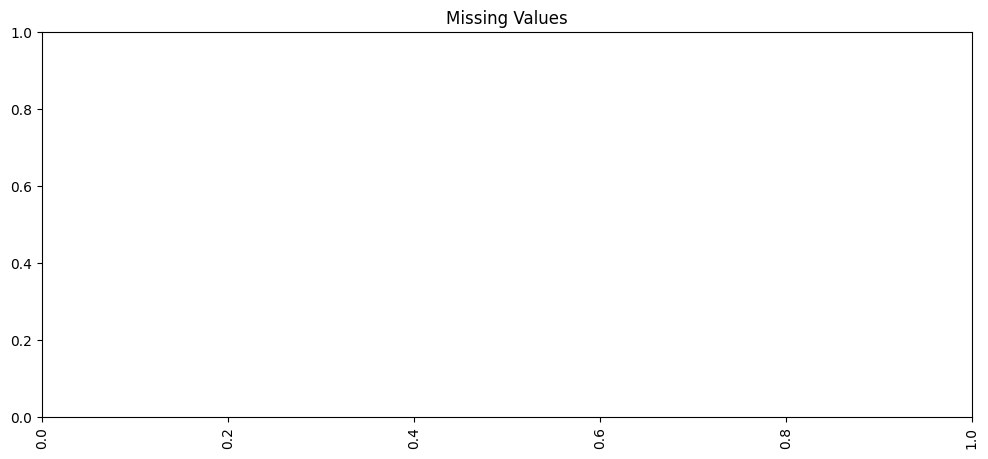

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=missing.index,y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values")
plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,54600.0,2.629648e+01,4.067519e+00,17.0,23.0,26.0,29.0,39.0
jersey_number,54600.0,1.350000e+01,7.500069e+00,1.0,7.0,13.5,20.0,26.0
height_cm,54600.0,1.816543e+02,6.277792e+00,163.0,177.0,182.0,186.0,200.0
weight_kg,54600.0,7.575485e+01,3.951481e+00,65.0,73.0,76.0,78.0,87.0
market_value_eur,54600.0,2.008445e+07,2.718866e+07,528822.0,4444778.0,10271107.0,23420128.0,200000000.0
...,...,...,...,...,...,...,...,...
total_goals_tournament,54600.0,6.439927e-01,1.093781e+00,0.0,0.0,0.0,1.0,10.0
total_assists_tournament,54600.0,6.076007e-01,9.315267e-01,0.0,0.0,0.0,1.0,8.0
total_minutes_tournament,54600.0,2.723003e+02,1.168062e+02,0.0,184.0,268.0,359.0,615.0
player_of_match_awards,54600.0,3.065934e-02,2.065200e-01,0.0,0.0,0.0,0.0,4.0


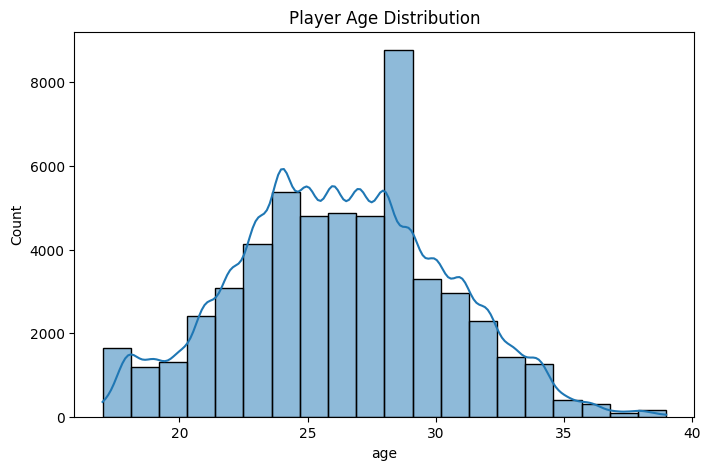

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Player Age Distribution")
plt.show()

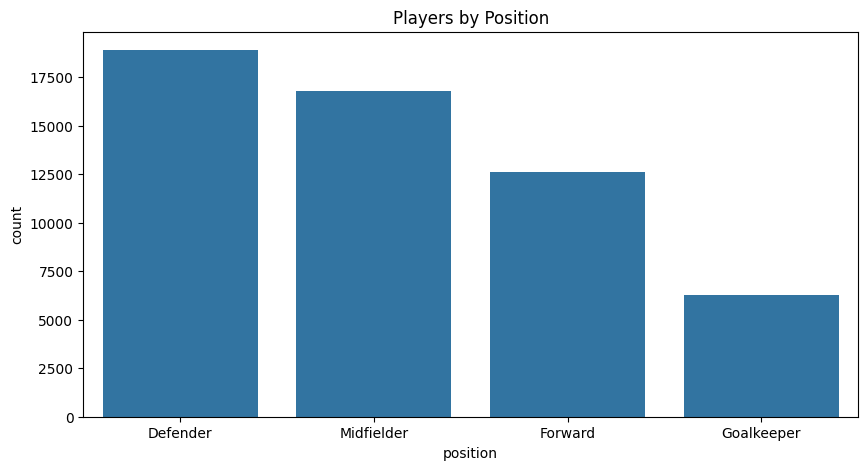

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="position",
    order=df["position"].value_counts().index
)

plt.title("Players by Position")
plt.show()


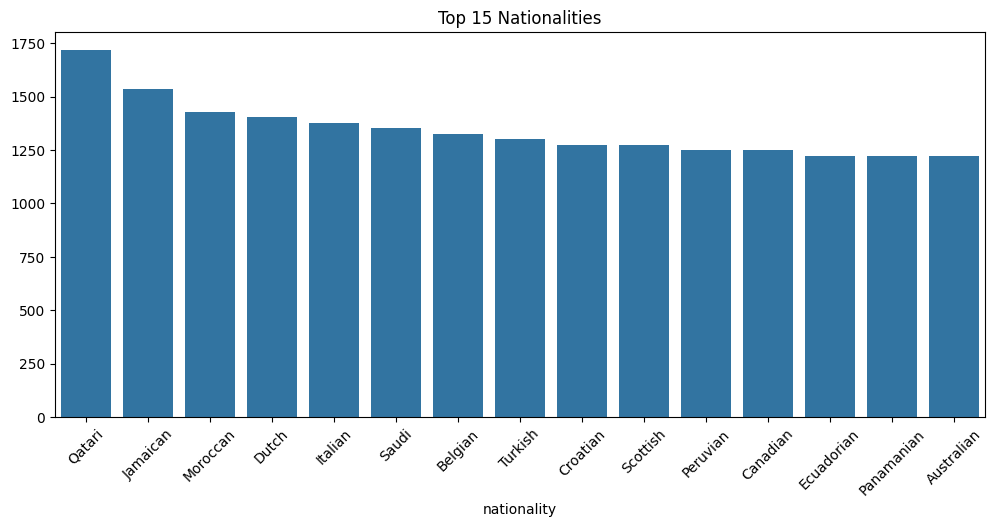

In [ ]:
top_countries = df["nationality"].value_counts().head(15)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)
plt.title("Top 15 Nationalities")
plt.show()


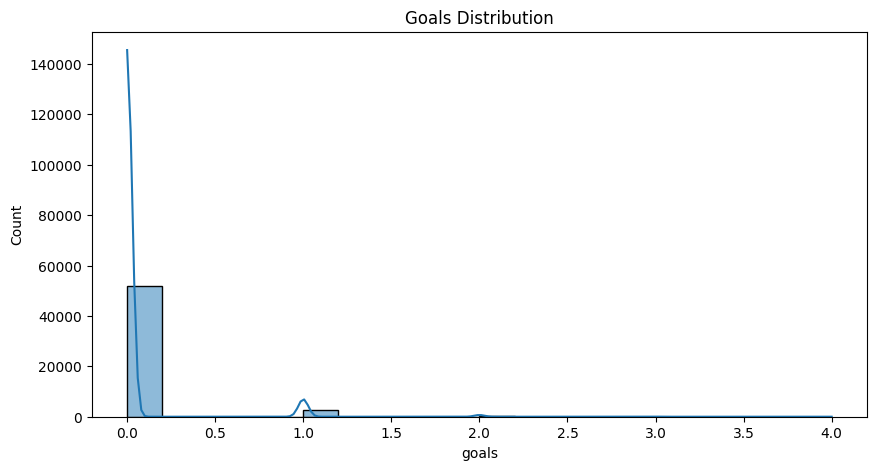

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["goals"],
    bins=20,
    kde=True
)

plt.title("Goals Distribution")
plt.show()


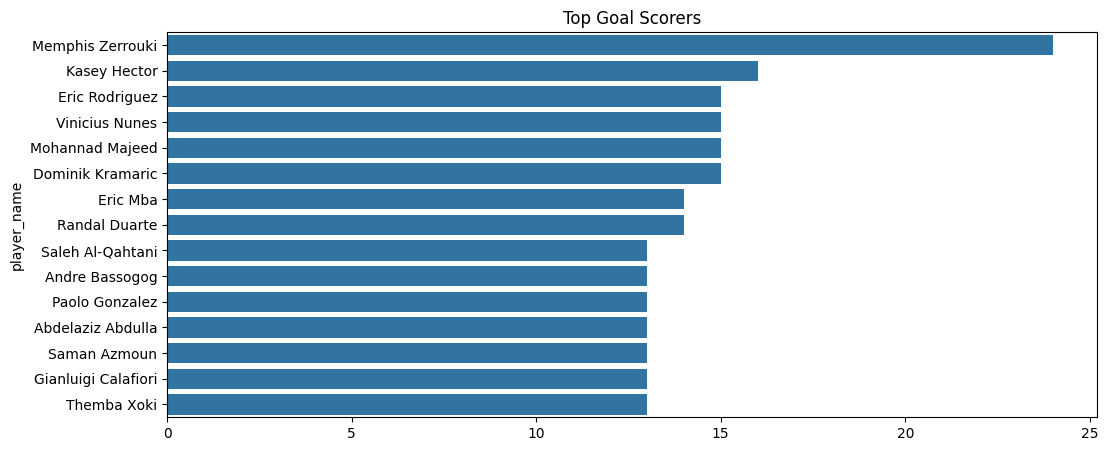

In [ ]:
top_goals = (
    df.groupby("player_name")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_goals.values,
    y=top_goals.index
)

plt.title("Top Goal Scorers")
plt.show()


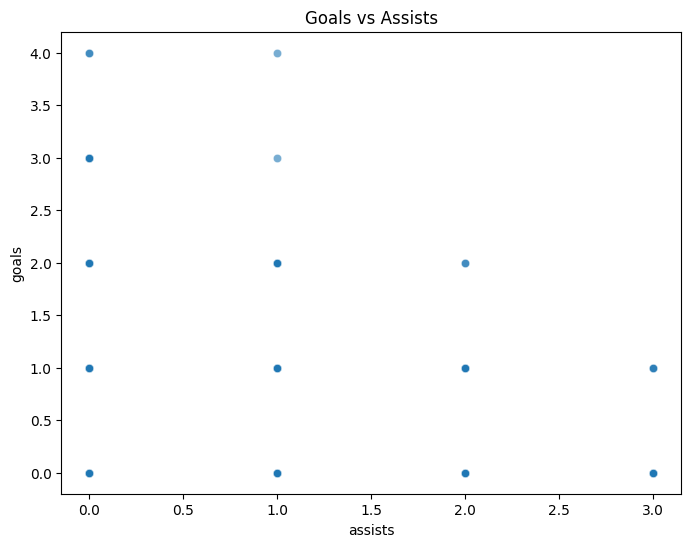

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="assists",
    y="goals",
    alpha=0.6
)

plt.title("Goals vs Assists")
plt.show()

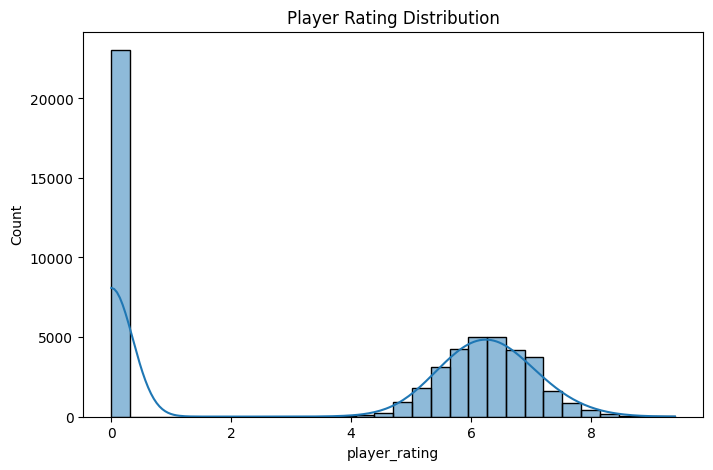

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["player_rating"],
    bins=30,
    kde=True
)

plt.title("Player Rating Distribution")
plt.show()

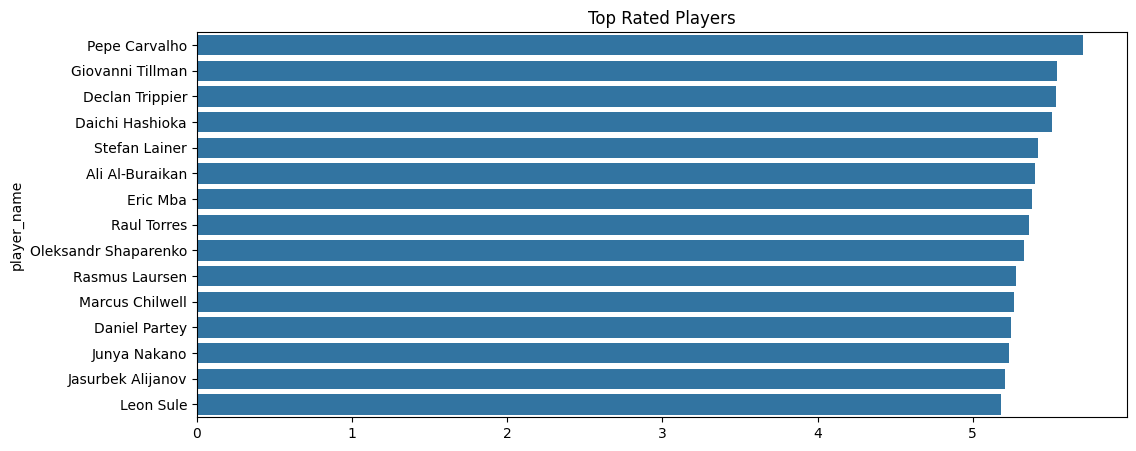

In [ ]:
top_players = (
    df.groupby("player_name")["player_rating"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_players.values,
    y=top_players.index
)

plt.title("Top Rated Players")
plt.show()

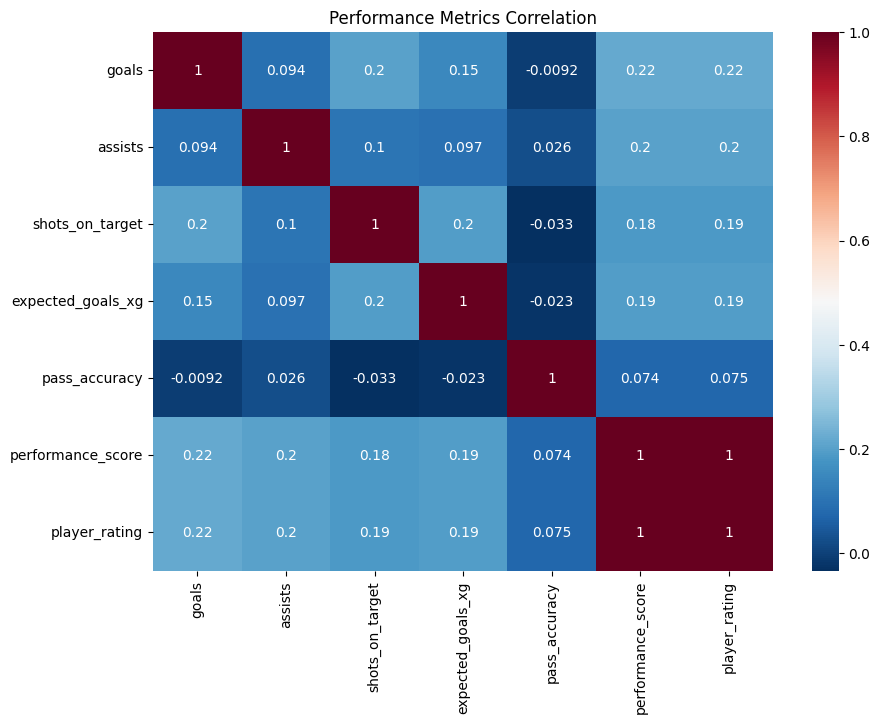

In [ ]:
perf_cols = [
    "goals",
    "assists",
    "shots_on_target",
    "expected_goals_xg",
    "pass_accuracy",
    "performance_score",
    "player_rating"
]

corr = df[perf_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r"
)

plt.title("Performance Metrics Correlation")
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Metric":[
        "Players",
        "Countries",
        "Teams",
        "Matches",
        "Goals",
        "Average Rating"
    ],
    "Value":[
        df["player_id"].nunique(),
        df["nationality"].nunique(),
        df["team"].nunique(),
        df["match_id"].nunique(),
        df["goals"].sum(),
        round(df["player_rating"].mean(),2)
    ]
})

summary

,Metric,Value
0,Players,1248.00
1,Countries,48.00
2,Teams,48.00
3,Matches,1050.00
4,Goals,3024.00
5,Average Rating,3.63


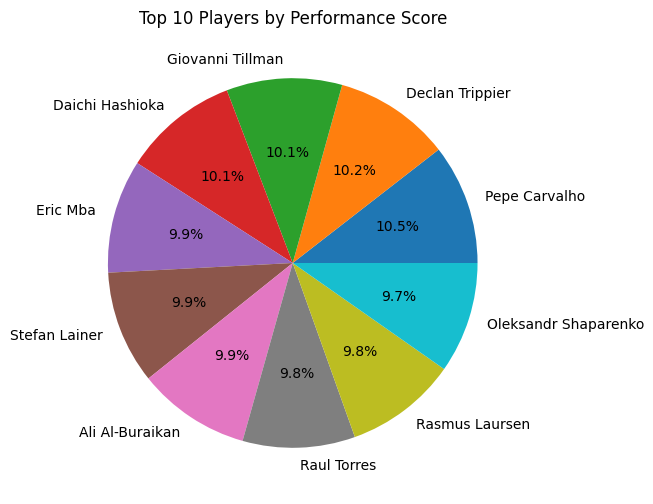

In [ ]:
top10 = (
    df.groupby("player_name")["performance_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.pie(
    top10.values,
    labels=top10.index,
    autopct="%1.1f%%"
)

plt.title("Top 10 Players by Performance Score")
plt.show()